# Übung 4

**Gruppenname:**

*ESM*

Gehen Sie wie folgt vor:

1. Kopieren Sie jetzt dieses Jupyter Notebook in Ihren Ordner (`Abgaben/Team_WXYZ`)

2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Falls Sie das Notebook im Browser bearbeiten, vergessen Sie nicht, es regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

werden Sie verschiedene Datensätze explorieren und dabei Ihre EDA-Fertigkeiten trainieren.

### 4.1 Visualisierung Teil 1 (Lebenserwartung)

In dieser Übung geht es darum, dass Sie Ihre Pandas- und Visualisierungs-Fähigkeiten weiter verfeinern. Wir werden die Entwicklung der Lebenserwartung der Weltbevölkerung in den letzten 200 Jahren untersuchen.

**Ihre Daten**

Die Daten stammen aus unterschiedlichen Datenquellen (unter anderem den United Nations, dem Institute for Health Metrics and Evaluation, der Human Mortality Database des Max Plank Instituts für demografische Forschung und der University of California Berkeley), die von der Gapminder Stiftung zusammengefasst wurden. Sie finden die Daten hier im Git Repository unter `data/life_expectancy_years.csv`.

**Ihre Aufgaben**

(1) Welche Erwartungshaltung haben Sie - ohne dass Sie vorher recherchieren: Was war die durchschnittliche Lebenserwartung eines Menschen zu Beginn des 19. Jahrhunderts (also 18XX) und im Jahr 2018? (1-3 Sätze)

In [2]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

# from less to more

data = pd.read_csv("./../data/life_expectancy_years.csv")

(2) Importieren und untersuchen Sie den hinterlegten Datensatz: Für welche Zeitspanne sind Daten hinterlegt?

In [3]:
# 1800 to 2018
data.dropna()
cols = data.columns

# data preparation
def get_time_ax():
    time_ax = [year for year in range(1800, 2011, 10)] # X
    time_ax.append(2018)
    return time_ax


def get_avg_per_country(country, time_ax, data=data):
    y = []
    figures = data[data["country"] == country]

    for index in range(len(time_ax)):

        t = time_ax [index]
        if index + 1 >= len(time_ax):
            y.append(np.mean(figures["2018"]))
            break        

        time_window = [i for i in range(2010, 2019)] if t == 2010 else [i for i in range(t, time_ax[index + 1] + 1)]
        le = np.array([figures[str(i)] for i in time_window])
        m = np.mean(le) 
        y.append(m)

    return y

X = get_time_ax()

Y_dta = [get_avg_per_country(c, X) for c in data["country"]]

Y_world = [np.mean(data[year]) for year in cols[1::]]

(3) Erstellen Sie eine Visualisierung der weltweiten Lebenserwartung ($y$-Achse) über die Jahre ($x$-Achse) hinweg. Halten Sie sich an die Regeln guter Visualisierung. Achten Sie auf Achsenbeschriftungen.

* Hinweis: Zur Bearbeitung dieser Aufgabe werden Sie im Netz recherchieren müssen.

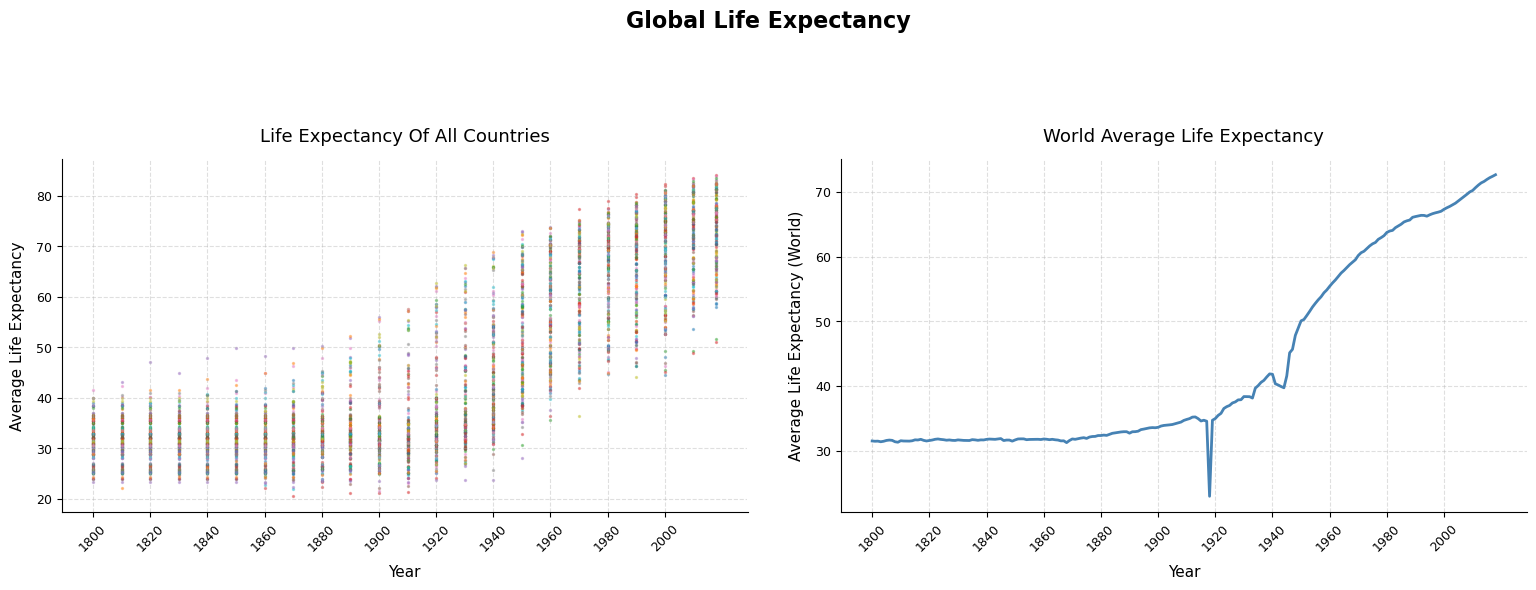

In [6]:
# Subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Global Life Expectancy", fontsize=16, fontweight="bold", y=1.02)

# Graph with all countries in different colors
for i in range(len(Y_dta)):
    ax[0].scatter(X, Y_dta[i], s=2, alpha=0.4)

ax[0].set_title("Life Expectancy Of All Countries", fontsize=13, pad=12)
ax[0].set_xlabel("Year", fontsize=11, labelpad=8)
ax[0].set_ylabel("Average Life Expectancy", fontsize=11, labelpad=8)
ax[0].set_xticks(np.arange(1800, 2019, 20))
ax[0].tick_params(axis="x", rotation=45, labelsize=9)
ax[0].tick_params(axis="y", labelsize=9)
ax[0].grid(True, linestyle="--", alpha=0.4)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

# Graph with the world average
ax[1].plot(np.arange(1800, 2019), Y_world, color="steelblue", linewidth=2)
ax[1].set_title("World Average Life Expectancy", fontsize=13, pad=12)
ax[1].set_xlabel("Year", fontsize=11, labelpad=8)
ax[1].set_ylabel("Average Life Expectancy (World)", fontsize=11, labelpad=8)
ax[1].set_xticks(np.arange(1800, 2019, 20))
ax[1].tick_params(axis="x", rotation=45, labelsize=9)
ax[1].tick_params(axis="y", labelsize=9)
ax[1].grid(True, linestyle="--", alpha=0.4)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

fig.tight_layout(pad=3.0)
plt.show()


(4) Vergleichen Sie Ihre Abbildung mit Ihrer Erwartungshaltung aus Schritt (1). Wurden Sie überrascht? Falls ja, inwiefern? (1-3 Sätze)

Nein, die Annahme, war dass die Lebenserwartung steigt mit ausnahme von Kriegen.

(5) Führen Sie eine kurze Recherche durch: Welche Ereignisse könnten die Einbrüche in der weltweiten Lebenserwartung, die Sie zu bestimmten Zeiten beobachten, erklären?

Krige, Krankheiten, Hungersnöte, Naturkatastrophen

(6) \[Optional\]: Vergleichen Sie die weltweite Lebenserwartung mit der von Deutschland: Erstellen Sie eine Visualisierung, die beide Graphen zeigt, und interpretieren Sie diese. (1-3 Sätze).

### 4.2 Visualisierung Teil 2 (Geburtenraten)

Dies ist eine Fortsetzung von vorherigen Übungsaufgaben. Wir kommen noch einmal auf Daten der Gapminder Stiftung zurück, um Geburtenraten weltweit zu untersuchen.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, im Git Repository unter `data/children_per_woman_total_fertility.csv`.

**Ihre Aufgaben**

(1) Importieren Sie den oben aufgeführten Datensatz.

In [27]:
data = pd.read_csv("./../data/children_per_woman_total_fertility.csv")

data

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Afghanistan,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00,...,6.04,5.82,5.60,5.38,5.17,4.98,4.80,4.64,4.48,4.33
1,Albania,4.60,4.60,4.60,4.60,4.60,4.60,4.60,4.60,4.60,...,1.65,1.65,1.67,1.69,1.70,1.71,1.71,1.71,1.71,1.71
2,Algeria,6.99,6.99,6.99,6.99,6.99,6.99,6.99,6.99,6.99,...,2.83,2.89,2.93,2.94,2.92,2.89,2.84,2.78,2.71,2.64
3,Angola,6.93,6.93,6.93,6.93,6.93,6.93,6.93,6.94,6.94,...,6.24,6.16,6.08,6.00,5.92,5.84,5.77,5.69,5.62,5.55
4,Antigua and Barbuda,5.00,5.00,4.99,4.99,4.99,4.98,4.98,4.97,4.97,...,2.15,2.13,2.12,2.10,2.09,2.08,2.06,2.05,2.04,2.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,Venezuela,5.63,5.63,5.64,5.64,5.64,5.65,5.65,5.65,5.66,...,2.50,2.47,2.44,2.42,2.39,2.37,2.34,2.32,2.29,2.27
180,Vietnam,4.70,4.70,4.70,4.70,4.70,4.70,4.70,4.70,4.70,...,1.94,1.95,1.95,1.96,1.96,1.96,1.96,1.95,1.95,1.95
181,Yemen,6.88,6.88,6.88,6.88,6.88,6.88,6.88,6.88,6.88,...,4.80,4.67,4.55,4.44,4.33,4.22,4.10,4.00,3.89,3.79
182,Zambia,6.71,6.71,6.71,6.71,6.71,6.71,6.71,6.71,6.71,...,5.48,5.40,5.32,5.24,5.17,5.10,5.04,4.98,4.93,4.87


(2) Visualisieren Sie die weltweite Geburtenrate ($y$-Achse) als Funktion der Zeit (Jahre, $x$-Achse). Achten Sie auf die Regeln guter Visualisierung, wie Sie sie in der Vorlesung kennengelernt haben. Beschriften Sie alle Achsen.

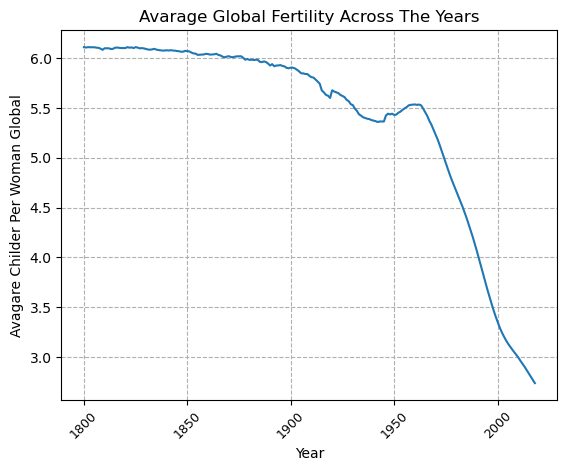

In [33]:

X = get_time_ax()
Y_word_2 = [np.mean(data[year]) for year in cols[1::]]

plt.title("Avarage Global Fertility Across The Years")
plt.grid(True, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Avagare Childer Per Woman Global")
plt.tick_params(axis="x", rotation=45, labelsize=9)
plt.plot(np.arange(1800, 2019), Y_word_2)


(3) Ab wann geht die Geburtenrate weltweit besonders stark zurück? (ungefähre Jahreszahl). Welche Hypothesen haben Sie, warum dieser Rückgang zu beobachten ist?

Ab 1950 dank der Einfuerung von Verhütungsmitteln, Aufklärung, Bildung, etc.

(4) Ermitteln Sie für jedes Jahr das Land, in dem die Geburtenrate am meisten zurückging. (Ein *Pandas Series* Objekt).

 * Zur Bearbeitung dieser Aufgabe werden Sie etwas nachdenken müssen. Wenn Sie partout nicht weiterkommen, lesen Sie diesen ROT13-kodierten Hinweis: Qre Uvajrvf ynhgrg: uggcf://cnaqnf.clqngn.bet/cnaqnf-qbpf/fgnoyr/ersrerapr/ncv/cnaqnf.QngnSenzr.qvss.ugzy

,country,min_val
1800,Denmark,4.04
1801,Denmark,4.04
1802,Norway,3.91
1803,Denmark,4.05
1804,Norway,3.94
...,...,...
2014,Singapore,1.25
2015,Singapore,1.24
2016,Moldova,1.24
2017,Moldova,1.23


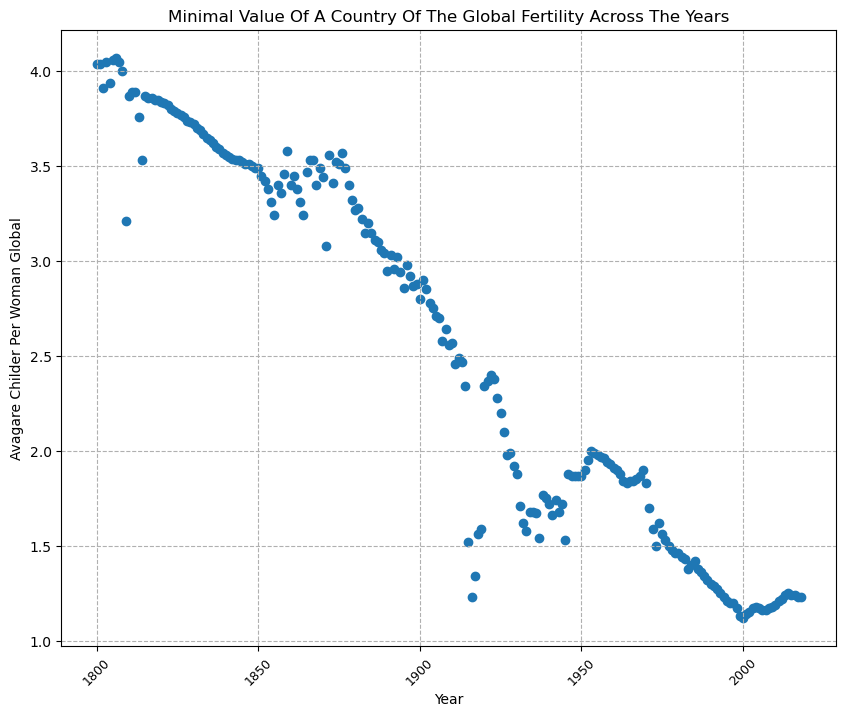

In [76]:
def get_min_per_year(data=data, time_frame=cols):
    return np.array([np.min(data[year]) for year in time_frame[1::]])


Y = get_min_per_year()

plt.figure(figsize=(10, 8))
plt.title("Minimal Value Of A Country Of The Global Fertility Across The Years")
plt.grid(True, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Avagare Childer Per Woman Global")
plt.tick_params(axis="x", rotation=45, labelsize=9)
plt.scatter(np.arange(1800, 2019), Y)


data_2 = data[cols[1::]]
min_idxs = data_2.idxmin()
country_names = [data.loc[i, 'country'] for (y, i) in min_idxs.items()]

res = pd.DataFrame({"country": country_names, "min_val": data_2.min()})
res


(5) Ermitteln Sie mit Ihrem Ergebnis aus Schritt (4) das Land, dessen Geburtenrate Ende der 80er und Anfang der 90er Jahre am stärksten zurückging. Um welches Land handelt es sich?

In [ ]:
def get_val(n):
    return n - 1800

print(res.iloc[get_val(1989)])
print(res.iloc[get_val(1990)])


country    Italy
min_val     1.32
Name: 1989, dtype: object
country    Italy
min_val      1.3
Name: 1990, dtype: object


219

(6) Visualisieren Sie den Zeitverlauf der Geburtenraten für das Land, welches Sie in Schritt (5) identifiziert haben. Achten Sie auf die Regeln guter Visualisierung, die Sie in der Vorlesung kennengelernt haben. Was Sie beobachten, zählt zu den schnellsten Geburtenrückgängen der Weltgeschichte.

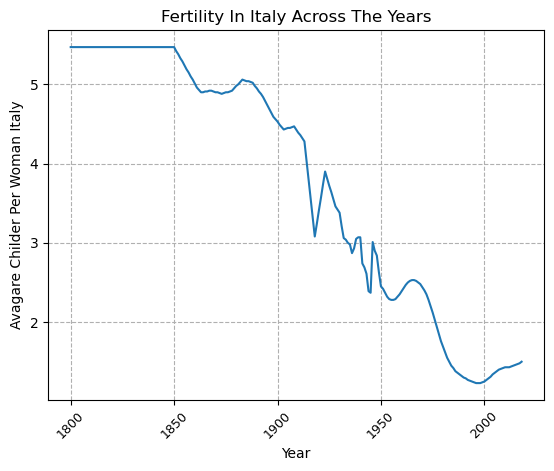

In [81]:
X = get_time_ax()
Y = data[data["country"] == "Italy"]
Y = [Y[y] for y in cols[1::]]

plt.title("Fertility In Italy Across The Years")
plt.grid(True, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Avagare Childer Per Woman Italy")
plt.tick_params(axis="x", rotation=45, labelsize=9)
plt.plot(np.arange(1800, 2019), Y)




(7) Fügen Sie der Abbildung aus Schritt (6) noch die Geburtenrate der USA als zusätzlichen Graphen hinzu. Beschreiben Sie grob den qualitativen Unterschied, den Sie feststellen (1-3 Sätze).

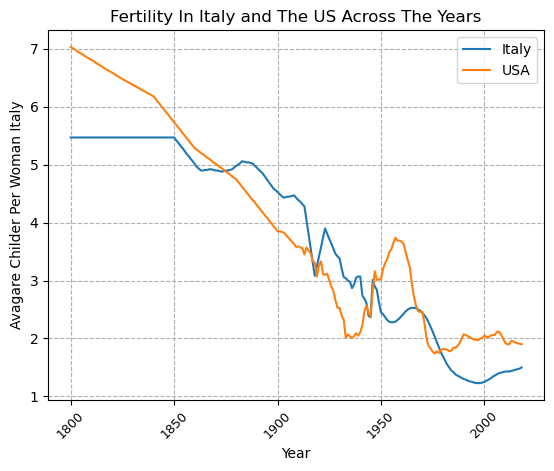

In [89]:
X = get_time_ax()
Y = data[data["country"] == "Italy"]
Y = [Y[y] for y in cols[1::]]

Y_us = data[data["country"] == "United States"]
Y_us = [Y_us[y] for y in cols[1::]]


plt.title("Fertility In Italy and The US Across The Years")
plt.grid(True, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Avagare Childer Per Woman Italy")
plt.tick_params(axis="x", rotation=45, labelsize=9)
plt.plot(np.arange(1800, 2019), Y, label='Italy')
plt.plot(np.arange(1800, 2019), Y_us, label="USA")
plt.legend()


**Schlussbemerkung** Wenn Sie mit Ihrer Aufgabe bis hierhin gekommen sind, dann lesen Sie gerne die ROT-13 kodierte Schlussbemerkung. Qre Vena ireorffregr Raqr qrf 20. Wnueuhaqregf qvr zrqvmvavfpur Irefbethat haq qvr Ovyqhat qre Oüetre qrhgyvpu. Rvar boyvtngbevfpur Frkhnynhsxyäehat, rvasnpure Mhtnat mh Ireuüghatfzvggrya (hagre naqrerz mhe Cvyyr) fbjvr rvar vz Vena orsvaqyvpur Xbaqbzsnoevx (qvr va qra 90re Wnuera teößgr Xbaqbzsnoevx jrygjrvg) jreqra mh qra irefpuvrqrara Snxgbera trmäuyg, qvr qra Trohegraeüpxtnat rexyäera.

### 4.3 Multivariate explorative Analyse (Mietspiegel)

In vielen Städte und Gemeinden werden sogenannte Mietspiegel erstellt, die eine Marktübersicht zu Miethöhen bereitstellen. Diese werden gerne von Sachverständigen, Vermietern und Mietinteressenten zurate gezogen. In §558, Absatz (2) des bürgerlichen Gesetzbuchs ist die ortsübliche Vergleichsmiete definiert: „Die ortsübliche Vergleichsmiete wird gebildet aus den üblichen Entgelten, die in der Gemeinde oder einer vergleichbaren Gemeinde für Wohnraum vergleichbarer Art, Größe, Ausstattung, Beschaffenheit und Lage einschließlich der energetischen Ausstattung und Beschaffenheit in den letzten vier Jahren vereinbart oder, von Erhöhungen nach §560 abgesehen, geändert worden sind.“ Das bedeutet für die Nettomiete, dass ihr Durchschnittswert in Abhängigkeit von Merkmalen wie Art, Größe, Ausstattung, Beschaffenheit und Lage der Wohnung zu bestimmen bzw. zu schätzen ist.

Im Rahmen dieser Übung werden Sie einen Mietspiegel aus München untersuchen, einer Gegend, die bekannt für außerordentlich hohe Mieten ist.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, im Git Repository unter `data/mietspiegel2015.txt`.

**Ihre Aufgaben**

(1) Importieren Sie die Daten.

In [92]:
data = pd.read_csv("./../data/mietspiegel2015.txt", sep=" ")
data

,nm,nmqm,wfl,rooms,bj,bez,wohngut,wohnbest,ww0,zh0,badkach0,badextra,kueche
0,608.40,12.67,48,2,1957.5,Untergiesing,0,0,0,0,1,0,0
1,780.00,13.00,60,2,1983.0,Bogenhausen,1,0,0,0,1,0,1
2,822.60,7.48,110,5,1957.5,Obergiesing,0,0,0,1,1,1,0
3,500.00,8.62,58,2,1957.5,Schwanthalerhöhe,0,0,0,0,1,0,1
4,595.00,8.50,70,3,1972.0,Aubing...,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3060,549.00,8.19,67,3,1957.5,Fledmoching-Hasenbergel,0,0,0,0,1,0,0
3061,873.50,11.80,74,3,1972.0,Bogenhausen,0,1,0,0,1,1,0
3062,1130.00,13.95,81,3,1972.0,Bogenhausen,0,1,0,0,1,1,0
3063,440.00,16.30,27,1,1972.0,Schwabing West,1,0,0,0,1,0,1


(2) Erzeugen Sie ein Säulendiagramm, dass die Häufigkeiten der Zimmeranzahl (rooms) zeigt.

Text(0, 0.5, 'Frequency')

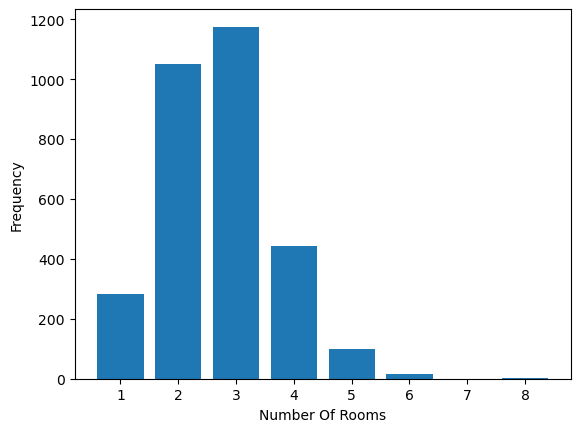

In [100]:
from collections import Counter

cols = data.columns

rooms = Counter(data["rooms"])

X = list(rooms.keys())
Y = list(rooms.values())

plt.bar(X, Y)
plt.xlabel("Number Of Rooms")
plt.ylabel("Frequency")


(3) Erstellen Sie eine 5-Number-Summary (Fünf-Punkte–Zusammenfassung) für die Variable Baujahr (bj). 

In [109]:
bj = data["bj"]

def get_summary(col):
    return {
        "median" : col.median(), 
        "min": col.min(),
        "obbere quantile" : col.quantile(0.75),
        "untere quantile" : col.quantile(0.25),
        "max" : col.max()
    }

get_summary(bj)


{'median': 1957.5,
 'min': 1918.0,
 'obbere quantile': np.float64(1983.0),
 'untere quantile': np.float64(1957.5),
 'max': 2012.5}

(4) Berechnen Sie die 5-Number-Summary für die Variablen Nettomiete (nm) und Nettomiete/Quadratmeter (nmqm), jeweils getrennt für Wohnungen, die vor bzw. nach dem Jahr 1958 gebaut wurden. Erstellen Sie ebenfalls die dazugehörigen Boxplots. Interpretieren Sie Ihre Ergebnisse. (1-3 Sätze)

In [ ]:
data_vor_1958 = data[data["bj"] > 1958]
data_nach_1958 = data[data["bj"] < 1958]

nm_vor_1958 = data_vor_1958["nm"]
nm_nach_1958 = data_nach_1958["nm"]

print("------------ nm --------------")
print("Vor 1958")
print(get_summary(nm_vor_1958))

print("Nach 1958")
print(get_summary(nm_nach_1958))

print("------------ nmqm --------------")

nmqm_vor_1958 = data_vor_1958["nmqm"]
nmqm_nach_1958 = data_nach_1958["nmqm"]

print("Vor 1958")
print(get_summary(nmqm_vor_1958))

print("Nach 1958")
print(get_summary(nmqm_nach_1958))



------------ nm --------------
Vor 1958
{'median': 735.0, 'min': 187.63, 'obbere quantile': np.float64(950.0), 'untere quantile': np.float64(590.0), 'max': 6000.0}
Nach 1958
{'median': 677.36, 'min': 174.75, 'obbere quantile': np.float64(872.0), 'untere quantile': np.float64(511.0), 'max': 3200.0}
------------ nmqm --------------
Vor 1958
{'median': 11.17, 'min': 4.24, 'obbere quantile': np.float64(12.62), 'untere quantile': np.float64(9.735), 'max': 21.01}
Nach 1958
{'median': 10.28, 'min': 2.47, 'obbere quantile': np.float64(12.19), 'untere quantile': np.float64(8.38), 'max': 22.13}


(5) Führen Sie die Analyse aus Schritt (4) noch einmal durch, allerdings schichten Sie hier Ihre Analyse nicht mehr nach "Baujahr vor oder nach 1958" sondern nach der Anzahl der Räume (rooms). Das bedeutet, dass Sie Boxplots der Nettomiete (nm), der Nettomiete/Quadratmeter (nmqm) in Abhängigkeit der Raumanzahl erstellen. Interpretieren Sie Ihre Ergebnisse. (1-3 Sätze).

(6) Erkunden Sie nun etwaige Zusammenhänge zwischen den Variablen Nettomiete (nm), Nettomiete/Quadratmeter (nmqm), Wohnfläche (wfl) und Anzahl der Räume (rooms), indem Sie einen [Scatter-Matrix-Plot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.scatter_matrix.html) erstellen.

(7) Interpretieren Sie den Ihren Plot aus Schritt 6: Sehen Sie Zusammenhänge zwischen einzelnen Variablen? (1-3 Sätze)

(8) Berechnen Sie Pearsons Korrelationskoeffizienten für alle Paare von Variablen aus Schritt (6). Schätzen Sie ein, welche Variablen miteinander schwach, mittel oder stark korreliert sind. Interpretieren Sie Ihre Ergebnisse (1-3 Sätze). Achten Sie dabei unter anderem auf Ihren Befund zwischen Zimmerzahl und Nettomiete/Quadratmeter sowie Nettomiete und Wohnfläche.

(9) Berechnen Sie [Spearmans Korrelationskoeffizient](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) für alle Paare von Variablen aus Schritt (6). Vergleichen Sie die Werte, die Sie erhalten, mit den Werten von Pearsons Korrelationskoeffizienten aus Schritt (8). Für welches Feature-Paar sehen Sie in beiden Koeffizienten die größten Unterschiede? Wie interpretieren Sie diesen Unterschied?

### 4.4 Pearsons Korrelationskoeffizient und Invarianz

Betrachten Sie die beiden Merkmale $X$ und $Y$ sowie ihre linearen Transformationen

$$\tilde{X} = a_X X + b_X, \quad a_X\neq 0$$

und

$$\tilde{Y} = a_Y Y + b_Y, \quad a_Y\neq 0$$


**Ihre Aufgabe**

Zeigen Sie, dass für Pearsons Korrelationskoeffizient $r_{XY}$ gilt:

$$ |r_{\tilde{X}\tilde{Y}}| = |r_{XY}|$$

Diese Invarianz unter linearen Transformationen wird auch *Maßstabsunabhängigkeit* genannt.